In [40]:
import os
import pandas as pd
import numpy as np
#import LanusStats  as ls
import soccerdata as sd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:

# fbref = ls.Fbref()

# print(ls.get_available_leagues('Fbref'))
# jugadores= fbref.get_all_player_season_stats("La Liga", "2024-2025", save_csv=False)
# #print(jugadores.head())
# print(jugadores.dtype())

fbref = sd.FBref('ENG-Premier League', '2021')

# Fetch data
games = fbref.read_schedule()
team_season_stats = fbref.read_team_season_stats(stat_type="standard")
player_season_stats = fbref.read_player_season_stats(stat_type="standard")
print(player_season_stats.head())

[09/14/26 10:42:34] INFO     Saving cached data to C:\Users\tela\soccerdata\data\FBref               ]8;id=14925878;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=14925879;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#250\250]8;;\

[09/14/26 10:42:37] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\_common.py:144: UserWarning: Season id "2021" is ambiguous:                  
                             interpreting as "20-21"                                                               
                               warnings.warn(msg, stacklevel=1)                                                    
                                                                                                                   

                    WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

                    WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[09/14/26 10:42:38] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

                                                         nation    pos age  \
                                                                             
league             season team    player                                     
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles    ENG  MF,DF  22   
                                  Alexandre Lacazette       FRA     FW  29   
                                  Bernd Leno                GER     GK  28   
                                  Bukayo Saka               ENG     MF  18   
                                  Calum Chambers            ENG     DF  25   

                                                          born Playing Time  \
                                                                         MP   
league             season team    player                                      
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles  1997           11   
                                  Alexandre Lacazette     1

In [29]:
print(player_season_stats.columns)

MultiIndex([(        'nation',       ''),
            (           'pos',       ''),
            (           'age',       ''),
            (          'born',       ''),
            (  'Playing Time',     'MP'),
            (  'Playing Time', 'Starts'),
            (  'Playing Time',    'Min'),
            (  'Playing Time',    '90s'),
            (   'Performance',    'Gls'),
            (   'Performance',    'Ast'),
            (   'Performance',    'G+A'),
            (   'Performance',   'G-PK'),
            (   'Performance',     'PK'),
            (   'Performance',  'PKatt'),
            (   'Performance',   'CrdY'),
            (   'Performance',   'CrdR'),
            ('Per 90 Minutes',    'Gls'),
            ('Per 90 Minutes',    'Ast'),
            ('Per 90 Minutes',    'G+A'),
            ('Per 90 Minutes',   'G-PK'),
            ('Per 90 Minutes', 'G+A-PK')],
           )


In [30]:
player_season_stats.head()

nation    pos age  \
                                                                             
league             season team    player                                     
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles    ENG  MF,DF  22   
                                  Alexandre Lacazette       FRA     FW  29   
                                  Bernd Leno                GER     GK  28   
                                  Bukayo Saka               ENG     MF  18   
                                  Calum Chambers            ENG     DF  25   

                                                          born Playing Time  \
                                                                         MP   
league             season team    player                                      
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles  1997           11   
                                  Alexandre Lacazette     1991           31   
                                  Bernd Leno              1992           35   
                                  Bukayo Saka             2001           32   
                                  Calum Chambers          1995           10   

                                                                             \
                                                         Starts   Min   90s   
league             season team    player                                      
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles      5   490   5.4   
                                  Alexandre Lacazette        22  1923  21.4   
                                  Bernd Leno                 35  3131  34.8   
                                  Bukayo Saka                30  2553  28.4   
                                  Calum Chambers              8   753   8.4   

                                                         Performance      ...  \
                                                                 Gls Ast  ...   
league             season team    player                                  ...   
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles           0   0  ...   
                                  Alexandre Lacazette             13   2  ...   
                                  Bernd Leno                       0   0  ...   
                                  Bukayo Saka                      5   3  ...   
                                  Calum Chambers                   0   2  ...   

                                                                             \
                                                         G-PK PK PKatt CrdY   
league             season team    player                                      
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles    0  0     0    0   
                                  Alexandre Lacazette      10  3     3    3   
                                  Bernd Leno                0  0     0    0   
                                  Bukayo Saka               5  0     0    1   
                                  Calum Chambers            0  0     0    0   

                                                              Per 90 Minutes  \
                                                         CrdR            Gls   
league             season team    player                                       
ENG-Premier League 2021   Arsenal Ainsley Maitland-Niles    0            0.0   
                                  Alexandre Lacazette       0           0.61   
                                  Bernd Leno                1            0.0   
                                  Bukayo Saka               0           0.18   
                                  Calum Chambers            0            0.0   

                                                                            \
                                                           Ast   G+A  G-PK   
league             season team    player                                     
ENG-Premi

In [31]:
player_season_stats_shooting = fbref.read_player_season_stats(stat_type="shooting")
player_season_stats_playing_time = fbref.read_player_season_stats(stat_type="playing_time")
player_season_stats_keeper = fbref.read_player_season_stats(stat_type="keeper")
player_season_stats_misc = fbref.read_player_season_stats(stat_type="misc")

print(player_season_stats.columns, player_season_stats_shooting.columns, player_season_stats_playing_time.columns, player_season_stats_keeper.columns, player_season_stats_misc.columns)




[09/14/26 10:42:39] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[09/14/26 10:42:40] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[09/14/26 10:42:41] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[09/14/26 10:42:42] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

MultiIndex([(        'nation',       ''),
            (           'pos',       ''),
            (           'age',       ''),
            (          'born',       ''),
            (  'Playing Time',     'MP'),
            (  'Playing Time', 'Starts'),
            (  'Playing Time',    'Min'),
            (  'Playing Time',    '90s'),
            (   'Performance',    'Gls'),
            (   'Performance',    'Ast'),
            (   'Performance',    'G+A'),
            (   'Performance',   'G-PK'),
            (   'Performance',     'PK'),
            (   'Performance',  'PKatt'),
            (   'Performance',   'CrdY'),
            (   'Performance',   'CrdR'),
            ('Per 90 Minutes',    'Gls'),
            ('Per 90 Minutes',    'Ast'),
            ('Per 90 Minutes',    'G+A'),
            ('Per 90 Minutes',   'G-PK'),
            ('Per 90 Minutes', 'G+A-PK')],
           ) MultiIndex([(  'nation',       ''),
            (     'pos',       ''),
            (     'age',       '

In [32]:
print(player_season_stats.columns, player_season_stats_shooting.columns, player_season_stats_playing_time.columns, player_season_stats_keeper.columns, player_season_stats_misc.columns)


MultiIndex([(        'nation',       ''),
            (           'pos',       ''),
            (           'age',       ''),
            (          'born',       ''),
            (  'Playing Time',     'MP'),
            (  'Playing Time', 'Starts'),
            (  'Playing Time',    'Min'),
            (  'Playing Time',    '90s'),
            (   'Performance',    'Gls'),
            (   'Performance',    'Ast'),
            (   'Performance',    'G+A'),
            (   'Performance',   'G-PK'),
            (   'Performance',     'PK'),
            (   'Performance',  'PKatt'),
            (   'Performance',   'CrdY'),
            (   'Performance',   'CrdR'),
            ('Per 90 Minutes',    'Gls'),
            ('Per 90 Minutes',    'Ast'),
            ('Per 90 Minutes',    'G+A'),
            ('Per 90 Minutes',   'G-PK'),
            ('Per 90 Minutes', 'G+A-PK')],
           ) MultiIndex([(  'nation',       ''),
            (     'pos',       ''),
            (     'age',       '

In [34]:
print(f"Indices: {player_season_stats.index}")
print(f"Columnas {player_season_stats.columns}")

Indices: MultiIndex([('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ('ENG-Premier League', '2021', 'Arsenal', ...),
            ...
            ('ENG-Premier League', '2021',  'Wolves', ...),
            ('ENG-Premier League', '2021',  'Wolves', ...),
            ('ENG-Premier League', '2021',  'Wolves', ...),
            ('ENG-Premier League', '2021',  'Wolves', ...),
            ('ENG-Premier League', '2021',  'Wolves', ...),
            ('ENG-Premier League', '2021',  'Wolves', ...),
            ('E

In [36]:
claves = ["player", "nation", "born", "pos", "age"]

dfs = [
    player_season_stats,
    player_season_stats_shooting,
    player_season_stats_playing_time,
    player_season_stats_keeper,
    player_season_stats_misc
]

for df_temp in dfs:
    if "player" not in df_temp.columns:
        df_temp.reset_index(inplace=True)

for df_temp in dfs:
    if isinstance(df_temp.columns, pd.MultiIndex):
        df_temp.columns = [
            f"{col[0]}_{col[1]}" if col[1] != "" else col[0]
            for col in df_temp.columns
        ]

columnas_repetidas = ["team", "season", "league"]

for df_temp in dfs[1:]:
    df_temp.drop(
        columns=[col for col in columnas_repetidas if col in df_temp.columns],
        inplace=True
    )
    
df = player_season_stats.merge(
    player_season_stats_shooting,
    on=claves,
    how="left"
)

df = df.merge(
    player_season_stats_playing_time,
    on=claves,
    how="left"
)

df = df.merge(
    player_season_stats_keeper,
    on=claves,
    how="left"
)

df = df.merge(
    player_season_stats_misc,
    on=claves,
    how="left"
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 85 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   league                 606 non-null    object 
 1   season                 606 non-null    object 
 2   team                   606 non-null    string 
 3   player                 606 non-null    string 
 4   nation                 605 non-null    string 
 5   pos                    606 non-null    string 
 6   age                    606 non-null    Int64  
 7   born                   606 non-null    Int64  
 8   Playing Time_MP_x      606 non-null    Int64  
 9   Playing Time_Starts_x  606 non-null    Int64  
 10  Playing Time_Min_x     606 non-null    Int64  
 11  Playing Time_90s_x     606 non-null    Float64
 12  Performance_Gls        606 non-null    Int64  
 13  Performance_Ast        606 non-null    Int64  
 14  Performance_G+A        606 non-null    Int64  
 15  Perfor

## Momento de intentar reducir la dimensionalidad, dando prioridad a las variables más relevantes

**Variables consideradas mas relevantes, eliminando redundancias a la vez, acabamos con 22 variables**

In [56]:
variables_pca = [
    # Producción ofensiva
    "Per 90 Minutes_Gls",
    "Per 90 Minutes_Ast",
    "Per 90 Minutes_G+A",
    "Per 90 Minutes_G-PK",
    "Per 90 Minutes_G+A-PK",
    
    # Tiros
    "Standard_Sh/90",
    "Standard_SoT/90",
    "Standard_SoT%",
    "Standard_G/Sh",
    "Standard_G/SoT",
    
    # Tiempo de juego
    "Playing Time_Min%",
    
    # Equipo
    "Team Success_PPM",
    "Team Success_+/-90",
    "Team Success_On-Off",
    
    # Defensa
    "Performance_Fls",
    "Performance_Fld",
    "Performance_Off",
    "Performance_Crs",
    "Performance_Int",
    "Performance_TklW",
    
    # Disciplina
    "Performance_CrdY_y",
    "Performance_CrdR_y"
]

In [59]:
df_sin_porteros = df[df["pos"] != "GK"].copy()
df_pca_data = df_sin_porteros[variables_pca].copy()

In [60]:
df_num = df_pca_data.select_dtypes(include=['number'])
df_num.index = df_sin_porteros['player']

In [61]:
df_num = df_num.dropna(axis=1)

In [62]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

In [63]:
pca = PCA(n_components=0.95)
df_pca= pca.fit_transform(df_scaled)

print(pca.n_components_)

9


In [64]:
pesos = pd.DataFrame(
    pca.components_.T, 
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index= df_num.columns
)
print(pesos)

                            PC1       PC2       PC3       PC4       PC5  \
Per 90 Minutes_Gls     0.385965 -0.089023 -0.215575 -0.282461 -0.156879   
Per 90 Minutes_Ast     0.249896  0.061162  0.574024 -0.013224  0.313609   
Per 90 Minutes_G+A     0.418845 -0.039944  0.106993 -0.226340  0.027408   
Per 90 Minutes_G-PK    0.375820 -0.100514 -0.228011 -0.310071 -0.176584   
Per 90 Minutes_G+A-PK  0.414992 -0.046790  0.111839 -0.246546  0.021146   
Standard_Sh/90         0.288325 -0.126311 -0.172391  0.487461 -0.023039   
Standard_SoT/90        0.246608 -0.124727 -0.272459  0.537141 -0.068137   
Performance_Fls        0.130461  0.432617 -0.141762  0.081984 -0.079814   
Performance_Fld        0.217371  0.326477  0.041893  0.191291 -0.012409   
Performance_Off        0.271617  0.063340 -0.019313  0.260868  0.232393   
Performance_Crs        0.124669  0.242309  0.449790  0.181413  0.083290   
Performance_Int       -0.042919  0.429660 -0.104952 -0.125974 -0.135652   
Performance_TklW       0.

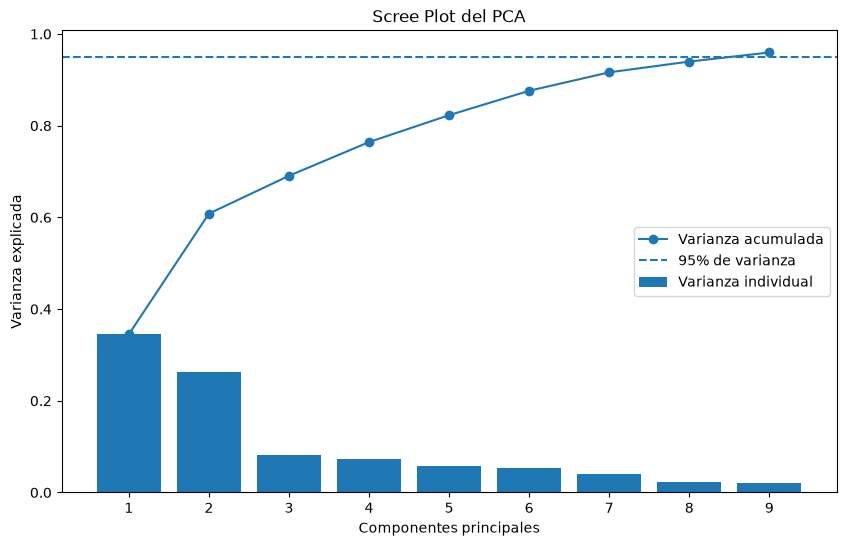

In [67]:
import numpy as np
import matplotlib.pyplot as plt

varianza = pca.explained_variance_ratio_
acumulada = np.cumsum(varianza)

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(varianza) + 1),
    varianza,
    label="Varianza individual"
)

plt.plot(
    range(1, len(acumulada) + 1),
    acumulada,
    marker="o",
    label="Varianza acumulada"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% de varianza"
)

plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot del PCA")
plt.xticks(range(1, len(varianza) + 1))
plt.legend()

plt.show()